<a href="https://colab.research.google.com/github/ElPunch/pneumonia-classification-deep-learning/blob/main/Proyecto_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Redireccionamiento de imagenes

In [ ]:
import os
from PIL import Image

# Define the input and output directories
# The actual image data is typically nested one level deeper in this dataset structure
input_data_root = os.path.join(path, 'chest_xray')
output_base_dir = './resized_chest_xray_balanced_limited'

# Define the target size
target_size = (244, 244)

# Limit the total number of images to process
MAX_TOTAL_IMAGES = 6000
# To ensure some balance, we can set a limit per sub-category (train/normal, train/pneumonia, etc.)
# There are 6 such primary categories under chest_xray (train, test, val each with NORMAL, PNEUMONIA)
MAX_PER_CATEGORY = MAX_TOTAL_IMAGES // 6
if MAX_TOTAL_IMAGES % 6 != 0:
    MAX_PER_CATEGORY += 1 # Distribute remainder to ensure total is met or slightly exceeded if needed

# Dictionary to keep track of processed images per category (e.g., 'train/NORMAL')
processed_counts = {}
total_processed_images = 0

print(f"Resizing up to {MAX_TOTAL_IMAGES} images (approx. {MAX_PER_CATEGORY} per category) to {target_size} and saving to '{output_base_dir}'...")

# Walk through the input directory structure
for root, dirs, files in os.walk(input_data_root):
    # Filter out __MACOSX directories from the list to be traversed by os.walk
    # This prevents the walk from entering these problematic directories
    dirs[:] = [d for d in dirs if d != '__MACOSX']

    # Determine the category for the current root (e.g., 'train/NORMAL')
    # relative_path from input_data_root gives 'train/NORMAL', 'train/PNEUMONIA', etc.
    relative_path = os.path.relpath(root, input_data_root)

    # Skip processing if we are at an intermediate directory level (like 'train', 'test', 'val')
    # or the root itself, as images are expected in sub-sub-directories
    if relative_path == '.' or len(relative_path.split(os.sep)) < 2:
        continue

    current_category = relative_path # e.g., 'train/NORMAL'
    if current_category not in processed_counts:
        processed_counts[current_category] = 0

    for file in files:
        if total_processed_images >= MAX_TOTAL_IMAGES:
            print(f"Reached maximum of {MAX_TOTAL_IMAGES} total images. Stopping.")
            break # Exit the inner loop (files)

        if processed_counts[current_category] >= MAX_PER_CATEGORY:
            # print(f"Reached maximum for category '{current_category}'. Skipping remaining files in this category.") # Optional: for debugging
            break # Exit the inner loop for this category, move to next root

        # Skip any metadata files like .DS_Store or files explicitly within __MACOSX paths
        if file.startswith('.') or '__MACOSX' in root:
            continue

        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_filepath = os.path.join(root, file)

            output_dir = os.path.join(output_base_dir, relative_path)
            os.makedirs(output_dir, exist_ok=True)
            output_filepath = os.path.join(output_dir, file)

            try:
                with Image.open(input_filepath) as img:
                    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
                    # Ensure correct format for saving based on file extension
                    if output_filepath.lower().endswith(('.jpeg', '.jpg')):
                        img_resized.save(output_filepath, format='JPEG')
                    elif output_filepath.lower().endswith('.png'):
                        img_resized.save(output_filepath, format='PNG')
                    else:
                        # Default to PNG if file type is ambiguous or other format
                        img_resized.save(output_filepath)

                    processed_counts[current_category] += 1
                    total_processed_images += 1
            except Exception as e:
                print(f"Error processing {input_filepath}: {e}")
    else:
        continue # Continue to the next root directory if inner loop completed normally
    break # Break the outer loop (root) if total_processed_images limit was reached

print(f"Image resizing complete! Total images processed: {total_processed_images}")
print("Processed counts per category:")
for category, count in processed_counts.items():
    print(f"- {category}: {count}")

Resizing up to 6000 images (approx. 1000 per category) to (244, 244) and saving to './resized_chest_xray_balanced_limited'...
Image resizing complete! Total images processed: 1640
Processed counts per category:
- chest_xray/val: 0
- chest_xray/val/PNEUMONIA: 8
- chest_xray/val/NORMAL: 8
- chest_xray/test: 0
- chest_xray/test/PNEUMONIA: 390
- chest_xray/test/NORMAL: 234
- chest_xray/train: 0
- chest_xray/train/PNEUMONIA: 1000


Limpieza de los datos

In [ ]:
import os
from PIL import Image
import pandas as pd

# The directory where the resized images are stored
output_base_dir = './resized_chest_xray_balanced_limited'

# Dictionary to store counts
image_counts = {
    'train': {'NORMAL': 0, 'PNEUMONIA': 0},
    'test': {'NORMAL': 0, 'PNEUMONIA': 0},
    'val': {'NORMAL': 0, 'PNEUMONIA': 0}
}

corrupted_images = []

print(f"Starting data cleaning and counting from: {output_base_dir}")

# Walk through the output directory structure
for root, dirs, files in os.walk(output_base_dir):
    # Extract the split (train, test, val) and class (NORMAL, PNEUMONIA)
    # The structure is expected to be e.g., './resized_chest_xray_balanced_limited/chest_xray/train/NORMAL'
    path_parts = root.split(os.sep)

    # Check if the path corresponds to a class directory (e.g., .../train/NORMAL or .../test/PNEUMONIA)
    if len(path_parts) >= 4 and path_parts[-2] in ['train', 'test', 'val'] and path_parts[-1] in ['NORMAL', 'PNEUMONIA']:
        split = path_parts[-2]
        img_class = path_parts[-1]

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)
                try:
                    with Image.open(filepath) as img:
                        img.verify() # Verify that it is an image
                        image_counts[split][img_class] += 1
                except Exception as e:
                    corrupted_images.append(filepath)
                    # print(f"Warning: Corrupted or unreadable image found and skipped: {filepath} ({e})")

print("\n--- Image Counts by Split and Class ---")
data_for_df = []
for split, classes in image_counts.items():
    for img_class, count in classes.items():
        data_for_df.append({'Split': split, 'Class': img_class, 'Count': count})

df_counts = pd.DataFrame(data_for_df)
print(df_counts.to_string(index=False))

print(f"\nTotal images processed: {df_counts['Count'].sum()}")

if corrupted_images:
    print(f"\n--- Detected Corrupted/Unreadable Images ({len(corrupted_images)} found) ---")
    for img_path in corrupted_images[:10]: # Print up to 10 corrupted paths
        print(img_path)
    if len(corrupted_images) > 10:
        print(f"... and {len(corrupted_images) - 10} more.")
else:
    print("\nNo corrupted or unreadable images detected in the processed dataset.")


Starting data cleaning and counting from: ./resized_chest_xray_balanced_limited

--- Image Counts by Split and Class ---
Split     Class  Count
train    NORMAL      0
train PNEUMONIA   1000
 test    NORMAL    234
 test PNEUMONIA    390
  val    NORMAL      8
  val PNEUMONIA      8

Total images processed: 1640

No corrupted or unreadable images detected in the processed dataset.


Analisis y visualizacion de los datos


--- Overall Class Distribution ---
    Class  Count
   NORMAL    242
PNEUMONIA   1398

--- Overall Class Distribution (Percentage) ---
    Class  Percentage
   NORMAL   14.756098
PNEUMONIA   85.243902


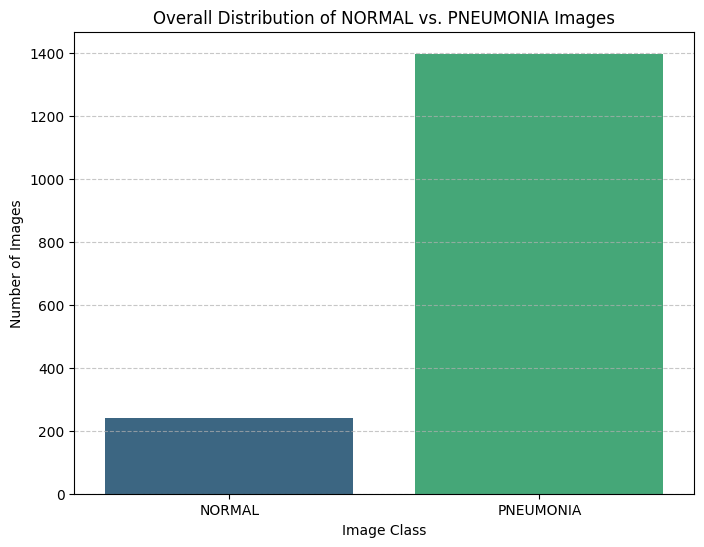

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate counts by class across all splits
overall_class_counts = df_counts.groupby('Class')['Count'].sum().reset_index()

print("\n--- Overall Class Distribution ---")
print(overall_class_counts.to_string(index=False))

# Calculate percentages
total_images = overall_class_counts['Count'].sum()
overall_class_counts['Percentage'] = (overall_class_counts['Count'] / total_images) * 100
print("\n--- Overall Class Distribution (Percentage) ---")
print(overall_class_counts[['Class', 'Percentage']].to_string(index=False))

# Visualize the overall class distribution
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Class', y='Count', data=overall_class_counts, palette='viridis', hue='Class', legend=False)
plt.title('Overall Distribution of NORMAL vs. PNEUMONIA Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Balanceo y Preprocesamiento del Dataset

In [ ]:
# Reconstrucción de splits estratificados a partir de las imágenes ya redimensionadas
# (el split original de la celda 2 quedó roto: train/NORMAL = 0 imágenes)
from sklearn.model_selection import train_test_split

all_filepaths, all_labels = [], []
for root, dirs, files in os.walk(output_base_dir):
    path_parts = root.split(os.sep)
    if path_parts[-1] in ['NORMAL', 'PNEUMONIA']:
        for f in files:
            fp = os.path.join(root, f)
            if fp not in corrupted_images and f.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_filepaths.append(fp)
                all_labels.append(path_parts[-1])

df_all = pd.DataFrame({'filepath': all_filepaths, 'label': all_labels})
print("Total de imágenes utilizables:", len(df_all))
print(df_all['label'].value_counts())

# Split estratificado 70% train / 15% val / 15% test
df_train, df_temp = train_test_split(df_all, test_size=0.30, stratify=df_all['label'], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.50, stratify=df_temp['label'], random_state=42)

print(f"\nTrain: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")
print("\nDistribución train:\n", df_train['label'].value_counts())

Total de imágenes utilizables: 1640
label
PNEUMONIA    1398
NORMAL        242
Name: count, dtype: int64

Train: 1148 | Val: 246 | Test: 246

Distribución train:
 label
PNEUMONIA    979
NORMAL       169
Name: count, dtype: int64


In [ ]:
# Balanceo: class weights (evita duplicar imágenes o interpolar píxeles con SMOTE)
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class_labels = np.array(df_train['label'])
weights = compute_class_weight(class_weight='balanced', classes=np.unique(class_labels), y=class_labels)
class_weights = dict(zip(range(len(np.unique(class_labels))), weights))
print("Class weights:", class_weights)

BATCH_SIZE = 32

# Augmentation solo en train (ayuda especialmente a la clase minoritaria NORMAL)
train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=15, zoom_range=0.15,
    width_shift_range=0.1, height_shift_range=0.1, horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    df_train, x_col='filepath', y_col='label', target_size=target_size,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=True, seed=42
)
val_generator = val_test_datagen.flow_from_dataframe(
    df_val, x_col='filepath', y_col='label', target_size=target_size,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
test_generator = val_test_datagen.flow_from_dataframe(
    df_test, x_col='filepath', y_col='label', target_size=target_size,
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

class_indices = train_generator.class_indices
print("Mapeo de clases:", class_indices)

Class weights: {0: np.float64(3.396449704142012), 1: np.float64(0.5863125638406538)}
Found 1148 validated image filenames belonging to 2 classes.
Found 246 validated image filenames belonging to 2 classes.
Found 246 validated image filenames belonging to 2 classes.
Mapeo de clases: {'NORMAL': 0, 'PNEUMONIA': 1}


Construcción y Entrenamiento (Base Model)

In [ ]:
# Modelo base: CNN diseñada manualmente (sin transfer learning ni modelos preentrenados)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model_base = Sequential([
    Input(shape=(target_size[0], target_size[1], 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_base.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_base.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 242, 242, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 121, 121, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 119, 119, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo base (usa los generadores y class_weights ya definidos)
EPOCHS_BASE = 15

history_base = model_base.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASE,
    class_weight=class_weights
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 174s 5s/step - accuracy: 0.5070 - loss: 0.7430 - val_accuracy: 0.8537 - val_loss: 0.5617
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 191s 5s/step - accuracy: 0.6960 - loss: 0.6643 - val_accuracy: 0.8659 - val_loss: 0.5264
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 160s 4s/step - accuracy: 0.7274 - loss: 0.5706 - val_accuracy: 0.8740 - val_loss: 0.3466
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 156s 4s/step - accuracy: 0.7657 - loss: 0.5225 - val_accuracy: 0.6667 - val_loss: 0.6070
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 158s 4s/step - accuracy: 0.7692 - loss: 0.5151 - val_accuracy: 0.8659 - val_loss: 0.3920
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 159s 4s/step - accuracy: 0.7631 - loss: 0.4799 - val_accuracy: 0.6504 - val_loss: 0.7712
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 165s 5s/step - accuracy: 0.8040 - loss: 0.4359 - val_accuracy: 0.7642 - val_loss: 0.4543
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 163s 5s/step - accuracy: 0.7883 - loss: 0.4477 - val_accuracy: 0.8537 - v

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 943ms/step
Accuracy: 0.8130 | Precision: 0.9711 | Recall: 0.8038 | F1: 0.8796

Classification Report:
               precision    recall  f1-score   support

      NORMAL       0.44      0.86      0.58        37
   PNEUMONIA       0.97      0.80      0.88       209

    accuracy                           0.81       246
   macro avg       0.70      0.83      0.73       246
weighted avg       0.89      0.81      0.83       246



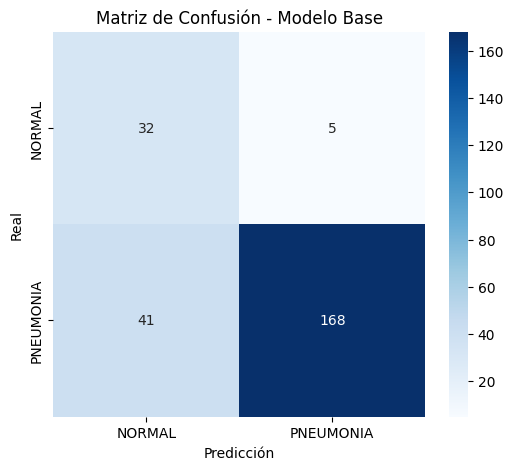

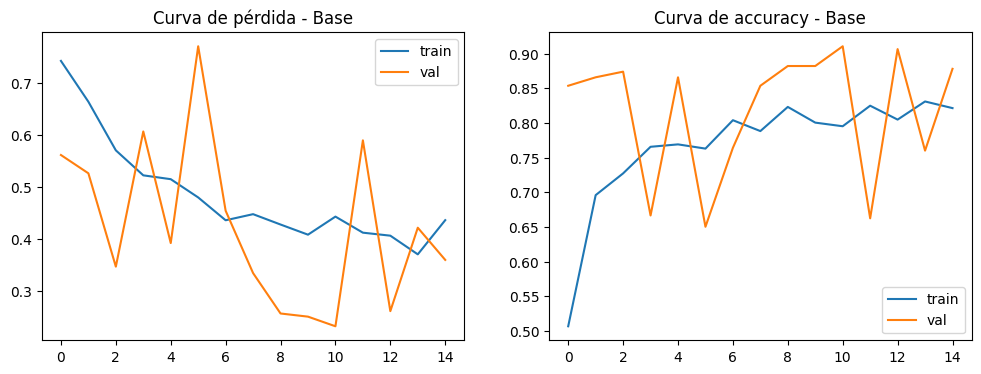

In [ ]:
# Evaluación del modelo base: métricas, curvas y matriz de confusión
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

test_generator.reset()
y_true = test_generator.classes
y_pred_prob_base = model_base.predict(test_generator)
y_pred_base = (y_pred_prob_base > 0.5).astype(int).ravel()

acc_base = accuracy_score(y_true, y_pred_base)
prec_base = precision_score(y_true, y_pred_base)
rec_base = recall_score(y_true, y_pred_base)
f1_base = f1_score(y_true, y_pred_base)
print(f"Accuracy: {acc_base:.4f} | Precision: {prec_base:.4f} | Recall: {rec_base:.4f} | F1: {f1_base:.4f}")

print("\nClassification Report:\n", classification_report(y_true, y_pred_base, target_names=list(class_indices.keys())))

cm = confusion_matrix(y_true, y_pred_base)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_indices.keys(), yticklabels=class_indices.keys())
plt.title('Matriz de Confusión - Modelo Base')
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12,4))
axs[0].plot(history_base.history['loss'], label='train')
axs[0].plot(history_base.history['val_loss'], label='val')
axs[0].set_title('Curva de pérdida - Base'); axs[0].legend()
axs[1].plot(history_base.history['accuracy'], label='train')
axs[1].plot(history_base.history['val_accuracy'], label='val')
axs[1].set_title('Curva de accuracy - Base'); axs[1].legend()
plt.show()

Fine-Tuning y Optimización

In [ ]:
# Modelo optimizado: no modifica model_base, agrega BatchNorm, Dropout progresivo y Adam con lr ajustado
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam

model_optimized = Sequential([
    Input(shape=(target_size[0], target_size[1], 3)),
    Conv2D(32, (3,3), activation='relu'), BatchNormalization(), MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'), BatchNormalization(), MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'), BatchNormalization(), MaxPooling2D(2,2),
    Conv2D(256, (3,3), activation='relu'), BatchNormalization(), MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'), Dropout(0.5),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_optimized.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_optimized.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 242, 242, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 242, 242, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 121, 121, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 119, 119, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 119, 119, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 59, 59, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 57, 57, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 57, 57, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 26, 26, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 26, 26, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │    11,075,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,482,689 (43.80 MB)

 Trainable params: 11,481,729 (43.80 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# Entrenamiento del modelo optimizado con callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

EPOCHS_OPT = 30

history_opt = model_optimized.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_OPT,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 266s 7s/step - accuracy: 0.7491 - loss: 1.3986 - val_accuracy: 0.8537 - val_loss: 1.8170 - learning_rate: 2.5000e-04
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 276s 8s/step - accuracy: 0.7030 - loss: 1.4101 - val_accuracy: 0.8537 - val_loss: 2.1949 - learning_rate: 2.5000e-04
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 265s 7s/step - accuracy: 0.7517 - loss: 0.9691 - val_accuracy: 0.8537 - val_loss: 2.0202 - learning_rate: 2.5000e-04
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 276s 8s/step - accuracy: 0.7047 - loss: 0.8690 - val_accuracy: 0.8537 - val_loss: 4.2575 - learning_rate: 2.5000e-04
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 270s 7s/step - accuracy: 0.7169 - loss: 0.7511 - val_accuracy: 0.8537 - val_loss: 4.6374 - learning_rate: 1.2500e-04
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 267s 7s/step - accuracy: 0.7230 - loss: 0.5448 - val_accuracy: 0.8537 - val_loss: 4.8643 - learning_rate: 1.2500e-04


In [ ]:
# Evaluación del modelo optimizado y comparación contra el modelo base
test_generator.reset()
y_pred_prob_opt = model_optimized.predict(test_generator)
y_pred_opt = (y_pred_prob_opt > 0.5).astype(int).ravel()

acc_opt = accuracy_score(y_true, y_pred_opt)
prec_opt = precision_score(y_true, y_pred_opt)
rec_opt = recall_score(y_true, y_pred_opt)
f1_opt = f1_score(y_true, y_pred_opt)

print("Classification Report - Optimizado:\n", classification_report(y_true, y_pred_opt, target_names=list(class_indices.keys())))

comparison_df = pd.DataFrame({
    'Modelo': ['Base', 'Optimizado'],
    'Accuracy': [acc_base, acc_opt],
    'Precision': [prec_base, prec_opt],
    'Recall': [rec_base, rec_opt],
    'F1 Score': [f1_base, f1_opt]
})
print("\n--- Comparación de Modelos ---")
print(comparison_df.to_string(index=False))

best_model_name = 'Optimizado' if f1_opt >= f1_base else 'Base'
best_model = model_optimized if f1_opt >= f1_base else model_base
print(f"\nMejor modelo según F1 Score: {best_model_name}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step
Classification Report - Optimizado:
               precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00        37
   PNEUMONIA       0.85      1.00      0.92       209

    accuracy                           0.85       246
   macro avg       0.42      0.50      0.46       246
weighted avg       0.72      0.85      0.78       246


--- Comparación de Modelos ---
    Modelo  Accuracy  Precision   Recall  F1 Score
      Base  0.813008   0.971098 0.803828  0.879581
Optimizado  0.849593   0.849593 1.000000  0.918681

Mejor modelo según F1 Score: Optimizado


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Exportación del Modelo

In [ ]:
# Exportación del mejor modelo obtenido
best_model.save('best_model.keras')
best_model.save('best_model.h5')
print(f"Modelo '{best_model_name}' exportado como 'best_model.keras' y 'best_model.h5'")

Modelo 'Optimizado' exportado como 'best_model.pkl'


In [ ]:
# Recarga del modelo exportado y ejemplo de inferencia
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

reloaded_model = load_model('best_model.keras')

def predict_image(img_path, model=reloaded_model, size=target_size):
    img = image.load_img(img_path, target_size=size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    prob = model.predict(img_array)[0][0]
    label = [k for k, v in class_indices.items() if v == int(prob > 0.5)][0]
    return label, prob

# Ejemplo de uso:
# etiqueta, probabilidad = predict_image(df_test['filepath'].iloc[0])
# print(etiqueta, probabilidad)